
# IBM HR Attrition — Improved Notebook

**What this notebook does (concise):**
- Clean and consistent EDA of the IBM HR Attrition dataset.
- Data preprocessing: encoding, scaling, handling class imbalance.
- Modeling pipeline: baseline model, hyperparameter tuning, cross-validation, evaluation (ROC, confusion matrix, classification report), and feature importance.
- Reproducible sections with explanatory text and concise, PEP8-friendly code blocks.

**Files used:** `WA_Fn-UseC_-HR-Employee-Attrition.csv`

Run this notebook from top to bottom in a fresh kernel. It is structured into sections:
1. Setup & imports
2. Data load & quick checks
3. EDA & visuals
4. Preprocessing & feature engineering
5. Model building & evaluation
6. Conclusions & next steps


In [1]:

# Setup: imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns

pd.options.display.max_columns = 200
pd.options.display.width = 200
np.random.seed(42)


In [2]:

# Load data
df = pd.read_csv(r"WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:

# Quick checks
print("Missing values per column:\n", df.isna().sum().sort_values(ascending=False).head(20))
print("\nData types:\n", df.dtypes.value_counts())
print("\nTarget distribution:\n", df['Attrition'].value_counts(normalize=True).map(lambda x: f"{x:.3f}"))


Missing values per column:
 Age                         0
StandardHours               0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
MonthlyIncome               0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
MonthlyRate                 0
MaritalStatus               0
Attrition                   0
EmployeeCount               0
dtype: int64

Data types:
 int64     26
object     9
Name: count, dtype: int64

Target distribution:
 Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: object


Numeric columns count: 26


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


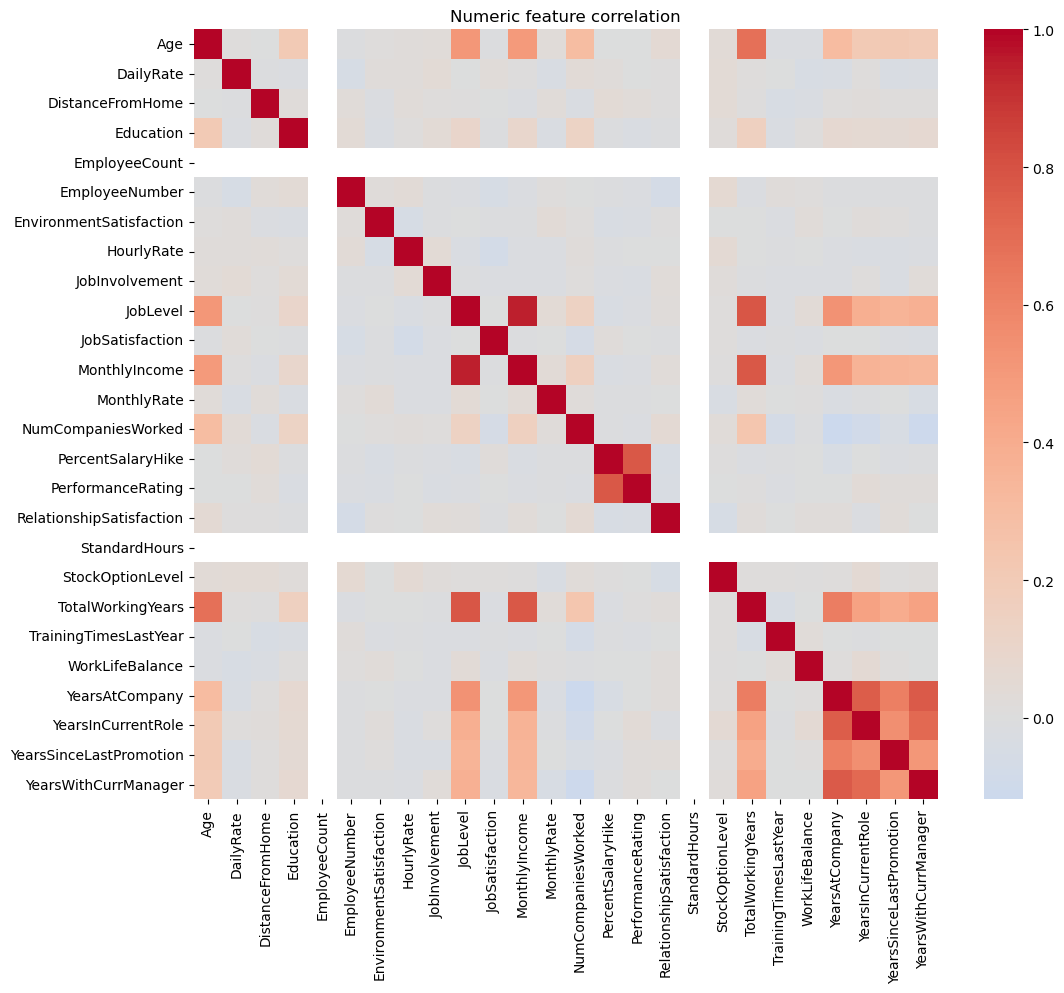

In [4]:

# EDA: numeric overview and correlations
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numeric columns count:", len(num_cols))

# Summary stats
display(df[num_cols].describe().T)

# Correlation heatmap (subset to avoid overcrowding)
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Numeric feature correlation")
plt.show()


In [5]:

# EDA: categorical distributions for top columns
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("Categorical columns count:", len(cat_cols))
for c in cat_cols[:10]:
    print("\n---", c, "---")
    display(df[c].value_counts().head(10))


Categorical columns count: 9

--- Attrition ---


Attrition
No     1233
Yes     237
Name: count, dtype: int64


--- BusinessTravel ---


BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


--- Department ---


...

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


--- Over18 ---


Over18
Y    1470
Name: count, dtype: int64


--- OverTime ---


OverTime
No     1054
Yes     416
Name: count, dtype: int64

In [6]:

# Preprocessing & feature engineering
target = 'Attrition'

# Separate features and target
X = df.drop(columns=[target])
y = df[target].map({'Yes':1, 'No':0})  # ensure binary numeric target

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()

# Simple pipeline: impute numeric with median + scale; impute categorical with most_frequent + one-hot encode
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [ ]:

# Modeling: baseline Random Forest with pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.show()

# Feature importances: only applicable after encoding; we'll extract feature names from preprocessor
preproc = clf.named_steps['preprocessor']
# numeric feature names
num_feats = numeric_features
# one-hot encoded categorical feature names
cat_onehot = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = list(num_feats) + list(cat_onehot)
importances = clf.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
display(feat_imp)


In [ ]:

# Hyperparameter tuning (small grid example)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(clf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("Best CV ROC AUC:", gs.best_score_)
best = gs.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print("ROC AUC (test):", roc_auc_score(y_test, y_proba))



## Conclusions & Next steps

**What we did**
- Cleaned and summarized the data.
- Built a preprocessing pipeline with sensible defaults for numeric and categorical features.
- Trained a Random Forest baseline and performed a small hyperparameter search.
- Evaluated model performance and inspected feature importances.

**Potential improvements**
- Handle class imbalance with SMOTE or class_weight adjustments.
- Try alternative models (XGBoost, LightGBM) and calibration for probabilities.
- Use SHAP for more reliable feature explanations.
- Perform more careful feature engineering (e.g., interaction terms, binning, date features).

**Notes**
- Always validate assumptions and check data leakage when engineering features.
